# Energy Weather Project

In [312]:
%pip install scikit-learn seaborn matplotlib pandas numpy
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

Note: you may need to restart the kernel to use updated packages.


In [313]:
df = pd.read_csv('Dataset Folder\energy_weather_raw_data.csv')

<>:1: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:1: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
C:\Users\Jbeck\AppData\Local\Temp\ipykernel_18984\2561010674.py:1: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  df = pd.read_csv('Dataset Folder\energy_weather_raw_data.csv')


## Data Preprocessing

In [314]:
#Test for null values
print(df.isnull().sum())

date              0
active_power      0
current           0
voltage           0
reactive_power    0
apparent_power    0
power_factor      0
main              0
description       0
temp              0
feels_like        0
temp_min          0
temp_max          0
pressure          0
humidity          0
speed             0
deg               0
temp_t+1          0
feels_like_t+1    0
dtype: int64


In [315]:
#No null values in the dataset
#Don't need date column for analysis
df.drop(columns=['date'], inplace=True)
df.head(5)

,active_power,current,voltage,reactive_power,apparent_power,power_factor,main,description,temp,feels_like,temp_min,temp_max,pressure,humidity,speed,deg,temp_t+1,feels_like_t+1
0,265.1,2.53,122.2,159.09,309.17,0.8575,Clear,clear sky,24.19,23.68,23.44,27.5,1013,39,0.0,0,29.63,27.97
1,265.1,2.53,122.2,159.09,309.17,0.8575,Clear,clear sky,24.19,23.68,23.44,27.5,1013,39,0.0,0,29.63,27.97
2,265.1,2.53,122.2,159.09,309.17,0.8575,Clear,clear sky,24.19,23.68,23.44,27.5,1013,39,0.0,0,29.63,27.97
3,640.0,5.45,120.7,152.08,657.82,0.9729,Clear,clear sky,24.19,23.68,23.44,27.5,1013,39,0.0,0,29.63,27.97
4,257.6,2.47,122.4,158.26,302.33,0.8520,Clear,clear sky,24.19,23.68,23.44,27.5,1013,39,0.0,0,29.63,27.97


In [316]:
#Temperature is in Celsius, convert to Fahrenheit
df['temp'] = df['temp'] * 9/5 + 32
df['feels_like'] = df['feels_like'] * 9/5 + 32
df["temp_min"] = df["temp_min"] * 9/5 + 32
df["temp_max"] = df["temp_max"] * 9/5 + 32
#Drop the temp_t+1 and feels_like_t+1 columns since they are not needed for the analysis
df.drop(columns=['temp_t+1', 'feels_like_t+1'], inplace=True)


#### One Hot Encoding

In [317]:
#Remove Description as it has too many unique values to be useful for modeling
#One hot encode the main column since it is categorical and has a small number of unique values
#Dont drop first to avoid clearing needed variables for modeling
df.drop(columns=['description'], inplace=True)
df = pd.get_dummies(df,columns=['main'], drop_first=False)

In [318]:
#Remove all electrical factors as it overfits the model and is not useful for prediction
df.drop(columns=['power_factor', 'apparent_power', 'reactive_power', 'voltage'], inplace=True)
df.drop(columns=['current'], inplace=True)

In [319]:
df.head(15)

,active_power,temp,feels_like,temp_min,temp_max,pressure,humidity,speed,deg,main_Clear,main_Clouds,main_Drizzle,main_Fog,main_Haze,main_Mist,main_Rain,main_Thunderstorm
0,265.1,75.542,74.624,74.192,81.500,1013,39,0.0,0,True,False,False,False,False,False,False,False
1,265.1,75.542,74.624,74.192,81.500,1013,39,0.0,0,True,False,False,False,False,False,False,False
2,265.1,75.542,74.624,74.192,81.500,1013,39,0.0,0,True,False,False,False,False,False,False,False
3,640.0,75.542,74.624,74.192,81.500,1013,39,0.0,0,True,False,False,False,False,False,False,False
4,257.6,75.542,74.624,74.192,81.500,1013,39,0.0,0,True,False,False,False,False,False,False,False
5,257.6,75.542,74.624,74.192,81.500,1013,39,0.0,0,True,False,False,False,False,False,False,False
6,257.6,75.542,74.624,74.192,81.500,1013,39,0.0,0,True,False,False,False,False,False,False,False
7,257.6,75.542,74.624,74.192,81.500,1013,39,0.0,0,True,False,False,False,False,False,False,False
8,257.6,75.542,74.624,74.192,81.500,1013,39,0.0,0,True,False,False,False,False,False,False,False
9,257.6,75.542,74.624,74.192,81.500,1013,39,0.0,0,True,False,False,False,False,False,False,False


### Model 1 (Linear Regression)

In [320]:
df_org = df
X = df.drop(columns=['active_power'])
y = df['active_power']
#Active power is the target variable, the rest are features
#Correlation matrix

In [321]:
#Train test split the data for prediction modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [322]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

In [323]:
print(f"r^2 Score: {r2_score(y_test, y_pred):.3f}")
print(f"MSE: {np.mean((y_test - y_pred) ** 2):.3f}")
print(f"MAE: {np.mean(np.abs(y_test - y_pred)):.3f}")

r^2 Score: 0.123
MSE: 31505.093
MAE: 124.648


<Axes: xlabel='Coefficient', ylabel='Feature'>

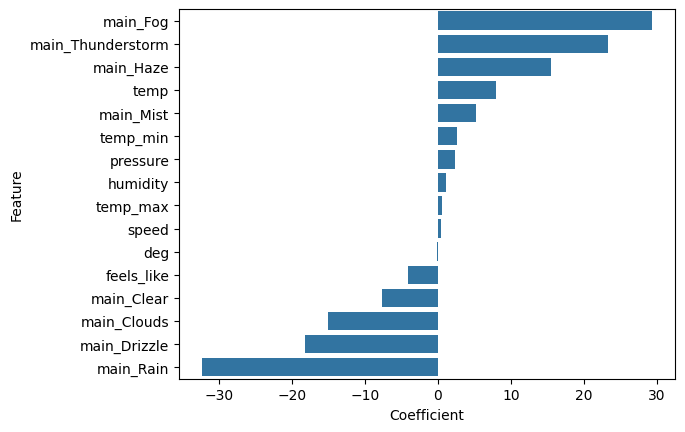

In [324]:
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr.coef_}).sort_values(by='Coefficient', ascending=False)
sns.barplot(x='Coefficient', y='Feature', data=coef_df)

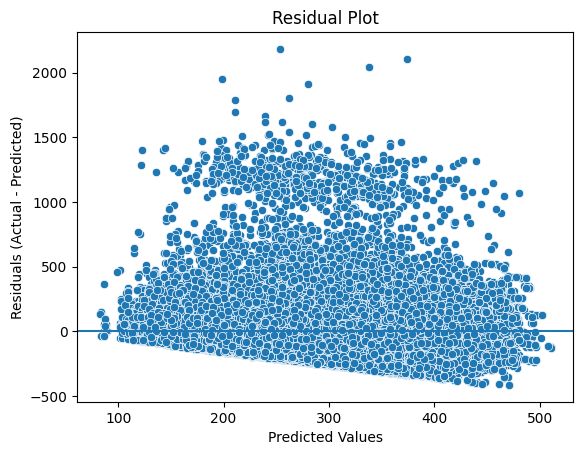

In [325]:
#Calculate Residuals for residual plot
residuals = y_test - y_pred
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")
plt.show()

### Model 2 (Decision Tree)

In [326]:
import sklearn.tree as tree
df2 = df_org.copy()

In [327]:
y2 = df2['active_power']
X2 = df2.drop(columns=['active_power'])
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)
dt = tree.DecisionTreeRegressor()
dt.fit(X_train2, y_train2)
y_pred2 = dt.predict(X_test2)
print(f"r^2 Score: {r2_score(y_test2, y_pred2):.3f}")
print(f"MSE: {np.mean((y_test2 - y_pred2) ** 2):.3f}")
print(f"MAE: {np.mean(np.abs(y_test2 - y_pred2)):.3f}")

r^2 Score: 0.607
MSE: 14107.740
MAE: 52.434


[Text(0.5, 0.9, 'feels_like <= 67.973\nsamples = 100.0%\nvalue = 285.897'),
 Text(0.25, 0.7, 'feels_like <= 62.969\nsamples = 55.9%\nvalue = 234.528'),
 Text(0.375, 0.8, 'True  '),
 Text(0.125, 0.5, 'deg <= 299.5\nsamples = 41.2%\nvalue = 220.994'),
 Text(0.0625, 0.3, 'deg <= 110.5\nsamples = 34.8%\nvalue = 215.056'),
 Text(0.03125, 0.1, '\n  (...)  \n'),
 Text(0.09375, 0.1, '\n  (...)  \n'),
 Text(0.1875, 0.3, 'humidity <= 47.5\nsamples = 6.4%\nvalue = 253.437'),
 Text(0.15625, 0.1, '\n  (...)  \n'),
 Text(0.21875, 0.1, '\n  (...)  \n'),
 Text(0.375, 0.5, 'deg <= 150.5\nsamples = 14.7%\nvalue = 272.347'),
 Text(0.3125, 0.3, 'temp_min <= 64.535\nsamples = 7.8%\nvalue = 292.317'),
 Text(0.28125, 0.1, '\n  (...)  \n'),
 Text(0.34375, 0.1, '\n  (...)  \n'),
 Text(0.4375, 0.3, 'temp_max <= 71.123\nsamples = 7.0%\nvalue = 250.093'),
 Text(0.40625, 0.1, '\n  (...)  \n'),
 Text(0.46875, 0.1, '\n  (...)  \n'),
 Text(0.75, 0.7, 'deg <= 174.5\nsamples = 44.1%\nvalue = 351.068'),
 Text(0.625, 0.8

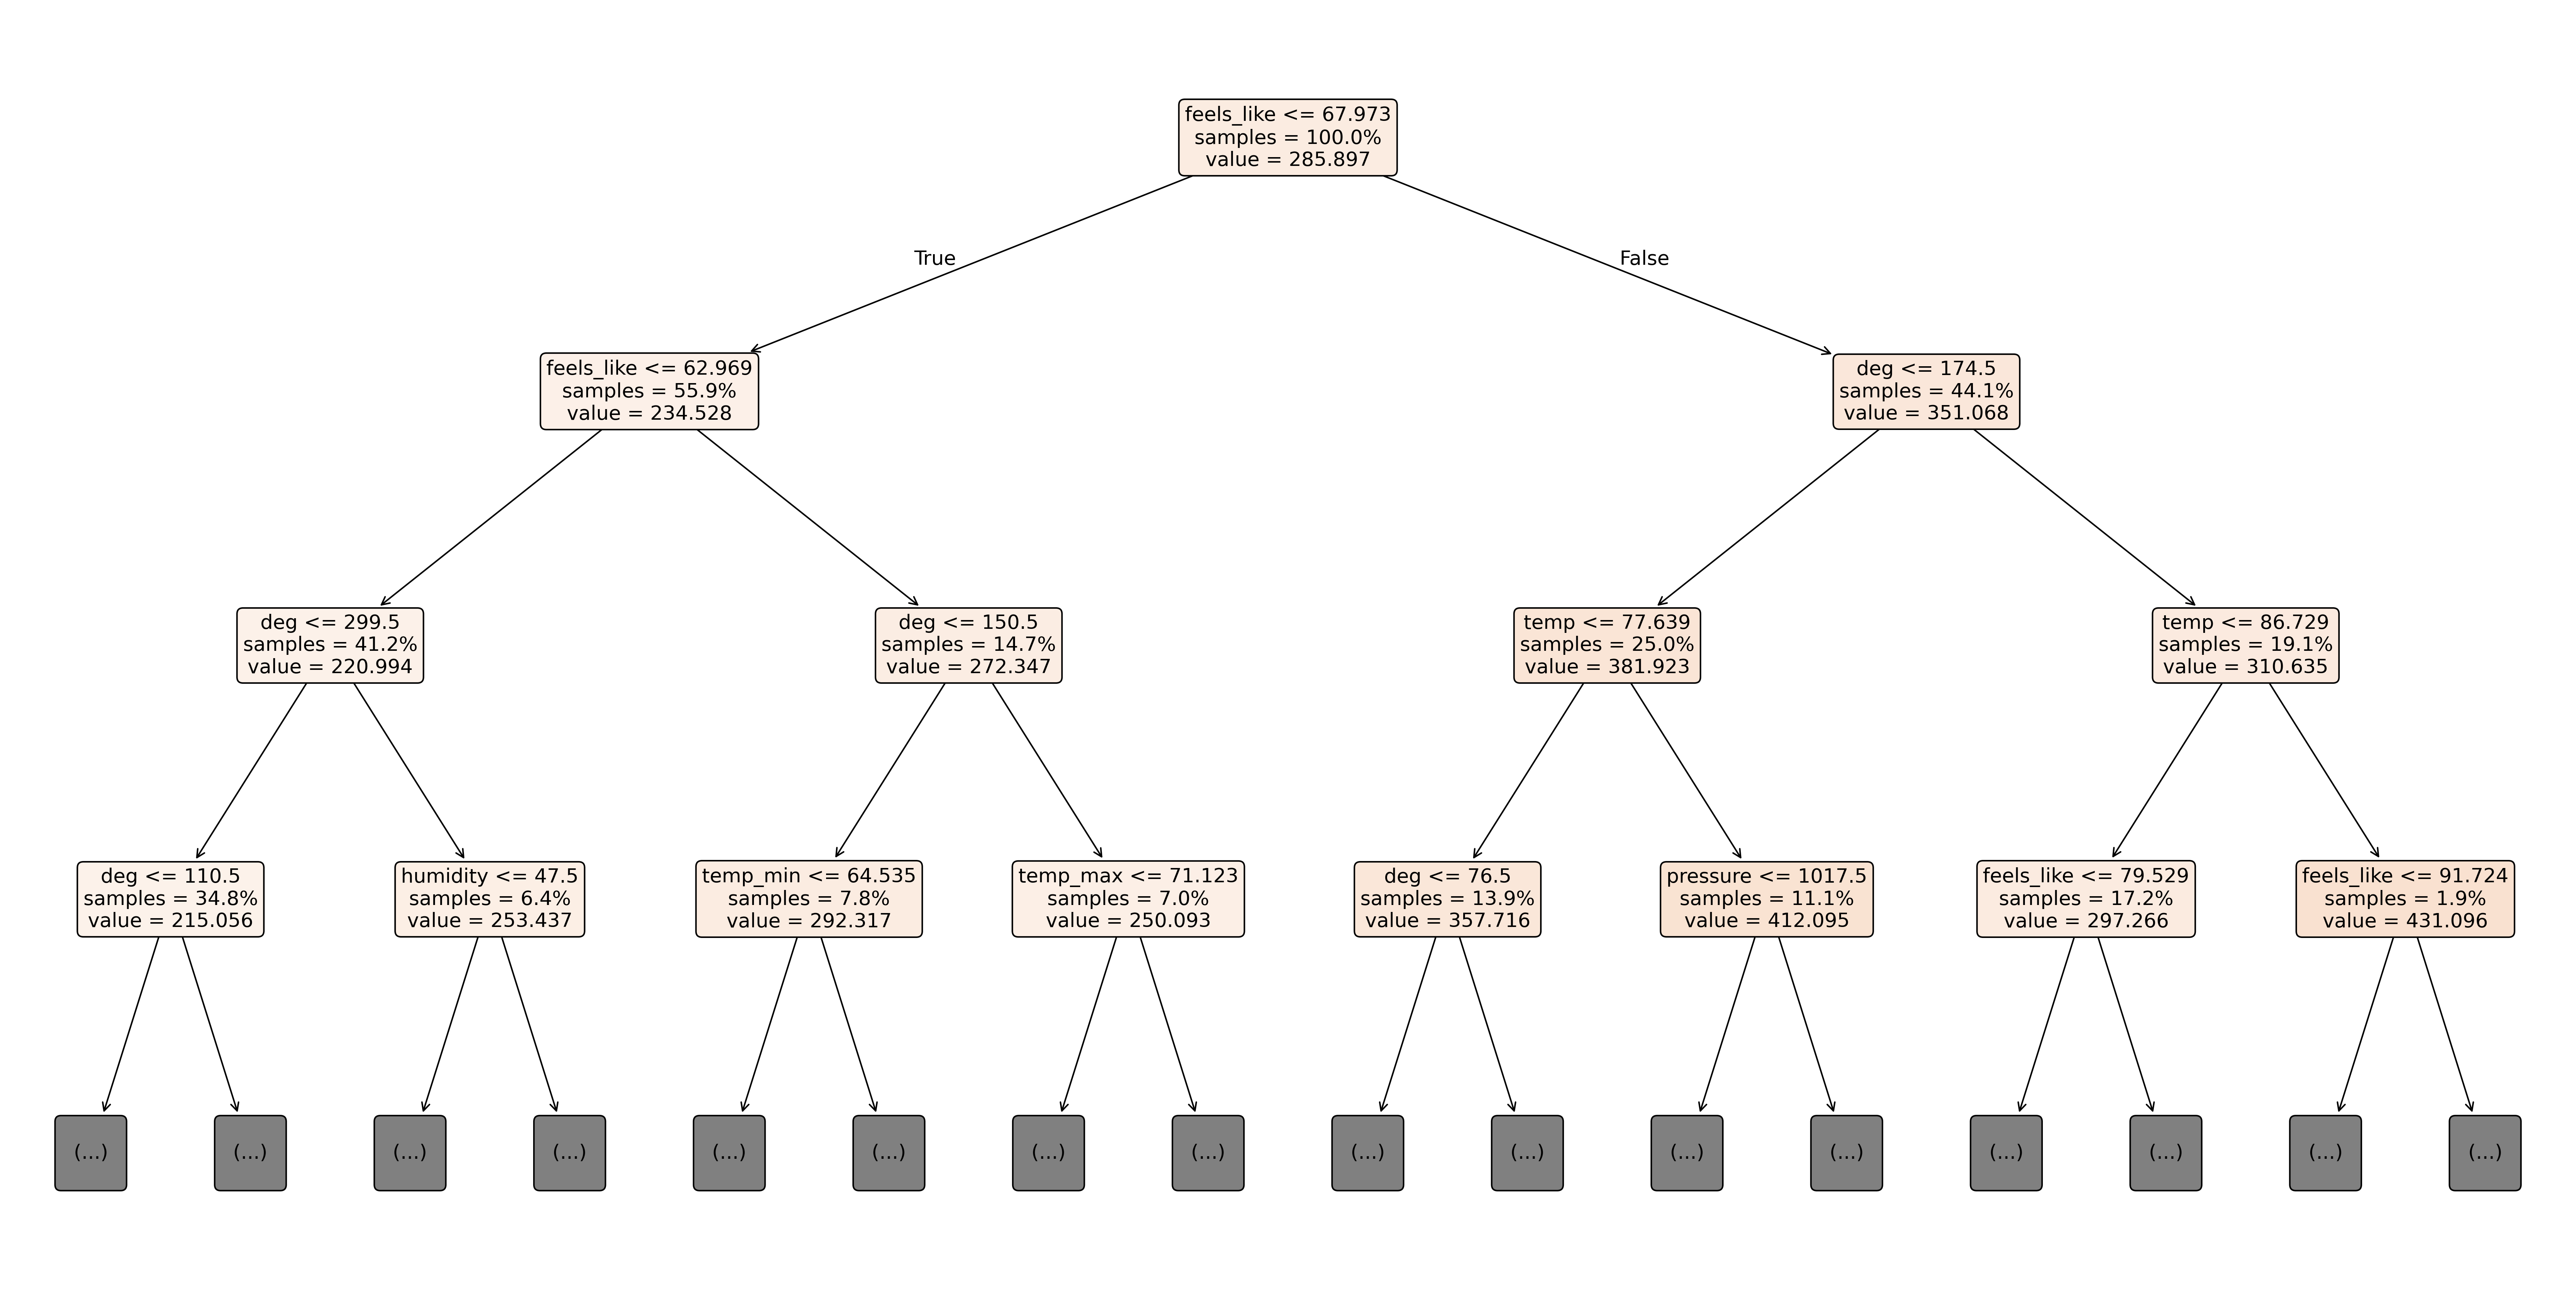

In [328]:
fig, axes = plt.subplots(figsize=(30, 15), dpi=300)

tree.plot_tree(
    dt,
    max_depth=3,
    feature_names=X2.columns,
    filled=True,
    rounded=True,
    fontsize=13,
    impurity=False,
    proportion=True
)

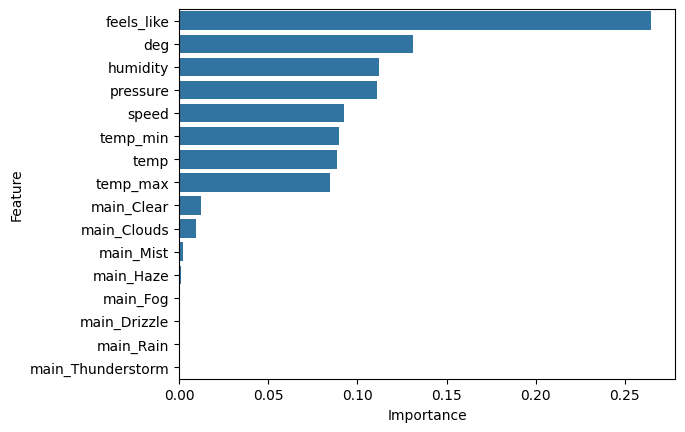

In [329]:
fi2 = pd.DataFrame({'Feature': X2.columns, 'Importance': dt.feature_importances_}).sort_values(by='Importance', ascending=False)
sns.barplot(x='Importance', y='Feature', data=fi2)
plt.show()

### Model 3 (Tuned Decision Tree)

In [ ]:
#We now will make a decision tree regressor testing different max depth and min samples leaf
#to see if we can improve the model performance.
from sklearn.model_selection import cross_val_score
depths = [5,10,30,50,100,500,None]
for depth in depths:
    model = tree.DecisionTreeRegressor(max_depth=depth)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    scores1 = cross_val_score(model, X, y, cv=5, scoring="r2")
    print(f"max_depth={depth} --> R^2 score: {scores1.mean():.4f}")

max_depth=5 --> R^2 score: -0.0373
max_depth=10 --> R^2 score: -0.1418


In [ ]:
leafs = [5,20,40,80,100,1000,1]
for leaf in leafs:
    model = tree.DecisionTreeRegressor(min_samples_leaf=leaf)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    scores1 = cross_val_score(model, X, y, cv=5, scoring="r2")
    print(f"min_samples_leaf={leaf} --> R^2 score: {scores1.mean():.4f}")

min_samples_leaf=5 --> R^2 score: -0.6864
min_samples_leaf=10 --> R^2 score: -0.6307
min_samples_leaf=20 --> R^2 score: -0.5258
min_samples_leaf=30 --> R^2 score: -0.4659
min_samples_leaf=40 --> R^2 score: -0.4187
min_samples_leaf=50 --> R^2 score: -0.3824
min_samples_leaf=80 --> R^2 score: -0.3138
min_samples_leaf=100 --> R^2 score: -0.2828
min_samples_leaf=1000 --> R^2 score: -0.0766


InvalidParameterError: The 'min_samples_leaf' parameter of DecisionTreeRegressor must be an int in the range [1, inf) or a float in the range (0.0, 1.0). Got None instead.

In [ ]:
df3 = df_org.copy()
y = df3['active_power']
X = df3.drop(columns=['active_power'])
X3_train, X3_test, y3_train, y3_test = train_test_split(X, y, test_size=0.2, random_state=42)
dt3 = tree.DecisionTreeRegressor(max_depth=5, min_samples_leaf=1000)
dt3.fit(X3_train, y3_train)
y_pred3 = dt3.predict(X3_test)
print(f"r^2 Score: {r2_score(y3_test, y_pred3):.3f}")
print(f"MSE: {np.mean((y3_test - y_pred3) ** 2):.3f}")
print(f"MAE: {np.mean(np.abs(y3_test - y_pred3)):.3f}")